# DATA 602 — AGN Classification: Logistic Regression & SVM

**Authors:** DATA 602 Team  
**Dataset:** `train_dataset.csv` (labeled) · `test_dataset.csv` (unlabeled inference)

---

## Project Goal

We want to build a machine learning model that can look at measurements of a galaxy and automatically decide: **is this an AGN (Active Galactic Nucleus) or a normal galaxy?**

An AGN is a galaxy with an unusually bright, energetic center powered by a supermassive black hole actively consuming surrounding material. Identifying them automatically at scale is the core goal of this project.

This is a **binary classification** problem — every galaxy gets one of two labels:
- `1` = AGN  
- `0` = Non-AGN

We train and compare two models:
1. **Logistic Regression** — a fast, interpretable linear classifier
2. **Support Vector Machine (SVM) with RBF kernel** — a more flexible, non-linear classifier

---

###  Note on Redshift

Redshift (`z`) has been **intentionally excluded** from the feature set.

In the training dataset, all non-AGN galaxies happen to be at low redshift while AGN tend to be at higher redshift. This is an artifact of how the training set was assembled — not a physical truth. If we include redshift, the model will learn `high redshift → AGN` as a shortcut, which would not generalize to real galaxy populations where non-AGN exist at all redshifts.

---

###  Key Changes from Previous Version

This version addresses the following reviewer feedback:

1. **No median imputation** — Instead of filling `NaN` values with column medians (which would artificially fabricate measurements), we **drop rows that have missing values in the features being used**. Median imputation risks biasing the model with invented data; real astronomical surveys simply don't detect everything.

2. **Subset-based modeling** — Rather than only running models on all 20+ features (where any model tends to do well), we now run each model on **four separate feature subsets**:
   - **All features** — the full combined feature set
   - **Emission line ratios only** — spectroscopic AGN diagnostics (BPT, etc.)
   - **WISE infrared color differences only** — mid-IR photometric AGN selection
   - **SDSS/optical color differences only** — optical photometric diagnostics

   This is a stronger test: emission line subsets lose ~50% of rows (many galaxies lack spectroscopy), while photometric subsets keep nearly all rows.

3. **`inf` values → `NaN` → dropped** — Log-ratio features (e.g., `o3_hB = log10(OIII/Hβ)`) produce `±inf` when the denominator flux is zero. We convert `inf` to `NaN` first, then drop those rows along with other missing values.


---
## 0. Imports & Setup

We load all required Python libraries upfront:
- **`pandas` / `numpy`** — data manipulation and numerical operations
- **`matplotlib` / `seaborn`** — data visualization
- **`scikit-learn`** — preprocessing, models, and evaluation metrics

Note: `SimpleImputer` has been removed since we no longer impute missing values.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_score, recall_score,
    f1_score, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('All imports successful!')

All imports successful!


---
## 1. Load the Training Data

We read `train_dataset.csv` into a pandas DataFrame. This file contains **5,138 labeled galaxies**:
- 2,570 confirmed AGN (from XXL and MaNGA surveys)
- 2,568 non-AGN (from MPA-JHU catalog)

The target column is `is_AGN` — the binary label we are trying to predict.

In [3]:
df = pd.read_csv('train_dataset.csv')

print(f'Shape: {df.shape}')
print(f'\nClass balance (is_AGN):')
print(df['is_AGN'].value_counts())
print(f'\nAGN fraction: {df["is_AGN"].mean():.2%}')

Shape: (5138, 38)

Class balance (is_AGN):
is_AGN
1    2570
0    2568
Name: count, dtype: int64

AGN fraction: 50.02%


In [4]:
df.head()

,Unnamed: 0,ext_ID,objID,specObjID,z,u_mag,g_mag,r_mag,i_mag,z_mag,...,g-z,r-i,r-z,i-z,w1-w2,w1-w3,w1-w4,w2-w3,w2-w4,w3-w4
0,0,N_17_36,1237678888525824072,4.891026e+18,0.108212,18.90512,17.17459,16.29803,15.90310,15.57950,...,1.59509,0.39493,0.71853,0.32360,0.184,2.098,4.628,1.914,4.444,2.530
1,1,N_16_5,1237678888525562072,4.891043e+18,0.287298,20.92362,19.23653,17.77361,17.21519,16.87830,...,2.35823,0.55842,0.89531,0.33689,0.261,1.510,4.866,1.249,4.605,3.356
2,2,N_10_37,1237679255745790159,4.892067e+18,2.617279,20.75518,20.07779,20.11126,20.04045,19.70411,...,0.37368,0.07081,0.40715,0.33634,0.856,4.445,8.255,3.589,7.399,3.810
3,3,N_15_26,1237678879962497281,4.892074e+18,2.272744,21.07071,20.41719,20.32949,20.38523,20.00075,...,0.41644,-0.05574,0.32874,0.38448,0.787,4.932,8.559,4.145,7.772,3.627
4,4,N_10_33,1237679255745790329,4.892079e+18,0.636867,23.34155,21.70927,20.76383,19.45248,19.20684,...,2.50243,1.31135,1.55699,0.24564,0.683,4.505,7.126,3.822,6.443,2.621


In [5]:
df.describe()

,Unnamed: 0,objID,specObjID,z,u_mag,g_mag,r_mag,i_mag,z_mag,w1mpro,...,g-z,r-i,r-z,i-z,w1-w2,w1-w3,w1-w4,w2-w3,w2-w4,w3-w4
count,5138.000000,5.138000e+03,5.138000e+03,5138.000000,5138.000000,5138.000000,5138.000000,5138.000000,5138.000000,4593.000000,...,5138.000000,5138.000000,5138.000000,5138.000000,4593.000000,4593.000000,4593.000000,4593.000000,4593.000000,4593.000000
mean,2568.500000,1.237669e+18,4.310209e+18,0.552114,19.996178,18.866214,18.289314,17.980604,17.769544,14.833323,...,1.096670,0.308710,0.519770,0.211059,0.443777,-0.841051,6.265568,-1.284828,5.821791,7.106619
std,1483.357172,9.885442e+12,3.262229e+18,0.752586,2.218151,2.345372,2.375148,2.396725,2.425578,1.553816,...,0.759879,0.343098,0.456715,0.400956,0.432164,208.399094,1.196225,208.394249,0.988020,208.420495
min,0.000000,1.237646e+18,2.995820e+17,-0.001484,10.939320,10.666680,7.387960,10.090690,9.291862,8.012000,...,-8.052500,-11.014960,-7.819010,-8.229570,-0.844000,-9984.608000,-0.147000,-9984.667000,-0.111000,-0.153000
25%,1284.250000,1.237661e+18,1.395896e+18,0.054536,18.574830,17.305343,16.722268,16.381855,16.164910,13.926000,...,0.623723,0.206275,0.330465,0.116037,0.137000,3.182000,5.664000,2.719000,5.372000,2.160000
50%,2568.500000,1.237668e+18,2.660016e+18,0.120670,19.555985,18.224575,17.651655,17.312860,17.149760,14.868000,...,1.058080,0.334975,0.548810,0.228120,0.279000,3.726000,6.298000,3.230000,5.875000,2.790000
75%,3852.750000,1.237679e+18,8.147099e+18,0.877560,21.557588,21.011308,20.566425,20.266707,20.034903,15.993000,...,1.523990,0.428685,0.738537,0.326012,0.694000,4.163000,7.062000,3.668000,6.453000,3.340000
max,5137.000000,1.237680e+18,1.411109e+19,7.011245,28.898840,27.966370,22.437000,24.310340,25.097290,18.181000,...,11.716810,1.502150,2.977590,7.998290,2.175000,6.249000,9.350000,5.657000,8.600000,9991.913000


---
## 2. Exploratory Data Analysis (EDA)

Before building any model, we visualize the data to understand its structure, spot quality issues, and develop intuition for which features are informative.

### 2a. Missing & Infinite Values

Two types of problematic values exist in this dataset:

- **Missing values (NaN):** Common in multi-band astronomical surveys — a galaxy may not be detected in every telescope band. Crucially, **emission line flux measurements are only available for galaxies with optical spectroscopy**. Many galaxies in this dataset lack spectroscopic follow-up, so ~50% of rows are missing emission line ratio features. When running models on emission line subsets, we drop these rows rather than fabricating values.

- **Infinite values (±inf):** Arise from log-ratio features like `o3_hB = log10(OIII_flux / Hβ_flux)`. When the denominator flux is zero, the result is mathematically infinite. We convert these to `NaN` first, then drop those rows — a zero-flux denominator means the measurement is unusable, not just uncertain.

**Why we drop instead of impute:**  
Replacing a missing emission line ratio with the column median would invent a spectroscopic measurement that was never made. This could bias the model toward the median galaxy rather than flagging genuine data absence. For photometric features (SDSS/WISE colors), nearly all rows are complete, so dropping is a minor concern there anyway.

In [6]:
# Step 1: Replace ±inf with NaN across all numeric columns
# Log-ratio features (o3_hB, o3_o2, etc.) produce inf when the denominator flux is zero.
# We treat these as missing — a zero denominator means the ratio is unmeasurable.
df = df.replace([np.inf, -np.inf], np.nan)

# Step 2: Report missing values after the inf → NaN conversion
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print('=== Missing Values (after converting ±inf to NaN) ===')
print(missing_report[missing_report['missing_count'] > 0].sort_values('missing_%', ascending=False))

=== Missing Values (after converting ±inf to NaN) ===
        missing_count  missing_%
ne3_o2           2742      53.37
o3_o2            2240      43.60
o1_hA            2090      40.68
s2_hA            2014      39.20
n2_hA            1941      37.78
o3_hB            1846      35.93
w4mpro            545      10.61
w3mpro            545      10.61
w1mpro            545      10.61
w2mpro            545      10.61
w1-w2             545      10.61
w1-w3             545      10.61
w1-w4             545      10.61
w2-w3             545      10.61
w2-w4             545      10.61
w3-w4             545      10.61


In [7]:
# Summarize missingness by feature group so we can anticipate how many rows
# each subset-based model will use.

EMISSION_COLS = ['o3_hB', 'n2_hA', 's2_hA', 'o1_hA', 'o3_o2', 'ne3_o2']
WISE_COLS     = ['w1-w2', 'w1-w3', 'w1-w4', 'w2-w3', 'w2-w4', 'w3-w4']
SDSS_COLS     = ['u-g', 'u-r', 'u-i', 'u-z', 'g-r', 'g-i', 'g-z', 'r-i', 'r-z', 'i-z']

for group_name, cols in [
    ('Emission line ratios', EMISSION_COLS),
    ('WISE infrared colors', WISE_COLS),
    ('SDSS optical colors',  SDSS_COLS)
]:
    rows_complete = df[cols].dropna().shape[0]
    rows_dropped  = len(df) - rows_complete
    print(f'{group_name}:')
    print(f'  Complete rows: {rows_complete} / {len(df)}  '
          f'({rows_complete/len(df):.1%} kept, {rows_dropped/len(df):.1%} dropped)')
    print()

Emission line ratios:
  Complete rows: 2139 / 5138  (41.6% kept, 58.4% dropped)

WISE infrared colors:
  Complete rows: 4593 / 5138  (89.4% kept, 10.6% dropped)

SDSS optical colors:
  Complete rows: 5138 / 5138  (100.0% kept, 0.0% dropped)



### 2b. Class Balance & Redshift Distribution

We verify the dataset is roughly balanced, and plot the **redshift distribution by class** to visually demonstrate why redshift was excluded as a feature.

The plot shows that non-AGN in this training set are concentrated at low redshift while AGN span a much wider range. This is a consequence of the sample construction — non-AGN were drawn from MPA-JHU (local galaxies) while AGN include sources from XXL and MaNGA at higher redshifts. A model trained with `z` as a feature would exploit this as a spurious shortcut.

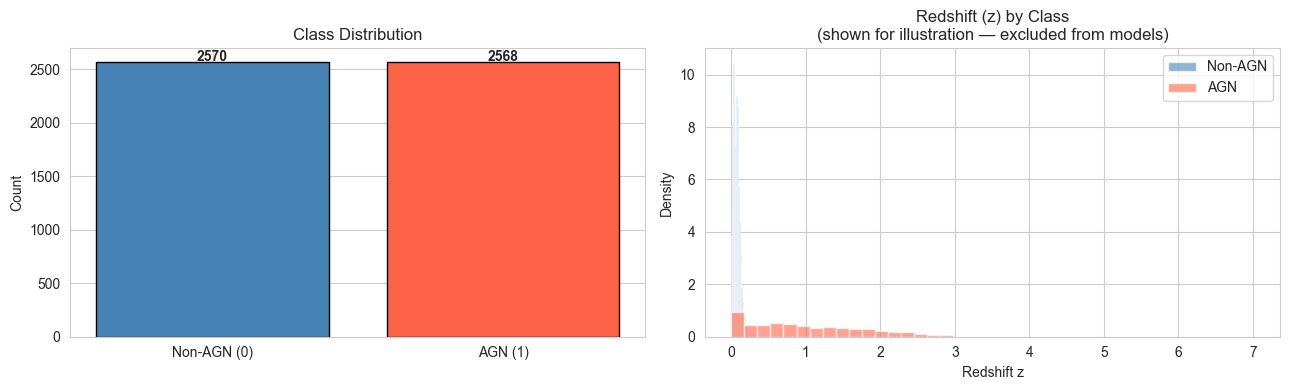

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class balance
counts = df['is_AGN'].value_counts()
axes[0].bar(['Non-AGN (0)', 'AGN (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Redshift — illustrative only, NOT used as a model feature
for label, color, name in [(0, 'steelblue', 'Non-AGN'), (1, 'tomato', 'AGN')]:
    axes[1].hist(df[df['is_AGN'] == label]['z'].dropna(), bins=40,
                 alpha=0.6, color=color, label=name, density=True)
axes[1].set_title('Redshift (z) by Class\n(shown for illustration — excluded from models)')
axes[1].set_xlabel('Redshift z')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2c. BPT Diagnostic Diagram

The **BPT diagram** (Baldwin, Phillips & Terlevich 1981) is the most widely used tool in observational astronomy for classifying galaxies using optical emission lines. It plots:

- **X-axis:** `n2_hA` = log₁₀([NII] / Hα) — nitrogen ionization relative to hydrogen
- **Y-axis:** `o3_hB` = log₁₀([OIII] / Hβ) — oxygen ionization relative to hydrogen

AGN produce harder UV radiation fields than star-forming regions, ionizing gas more powerfully. This causes AGN to appear in the **upper-right** of the diagram. Note that only galaxies with both measurements present are shown — this is the same subset that the emission-line model will train on.

Galaxies with both BPT measurements: 3150 / 5138 (61.3%)


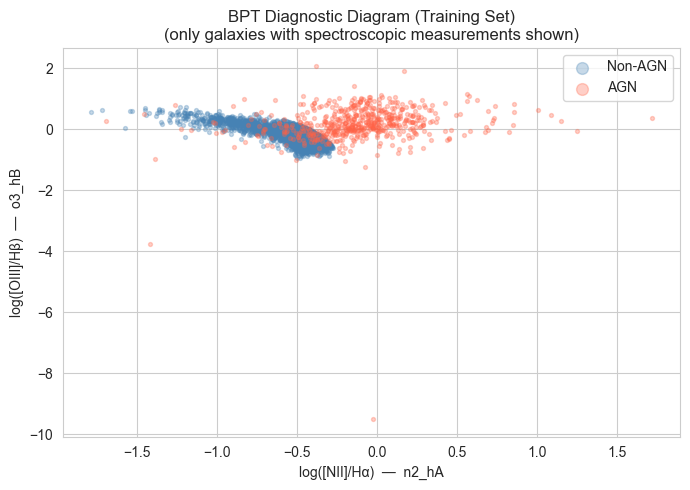

In [9]:
# Only plot rows where both BPT columns are present (no NaN, no inf)
# This directly reflects the data the emission-line model will see
bpt_mask = df['n2_hA'].notna() & df['o3_hB'].notna()
df_bpt = df[bpt_mask]
print(f'Galaxies with both BPT measurements: {len(df_bpt)} / {len(df)} ({len(df_bpt)/len(df):.1%})')

fig, ax = plt.subplots(figsize=(7, 5))
for label, color, name in [(0, 'steelblue', 'Non-AGN'), (1, 'tomato', 'AGN')]:
    subset = df_bpt[df_bpt['is_AGN'] == label]
    ax.scatter(subset['n2_hA'], subset['o3_hB'],
               alpha=0.3, s=8, c=color, label=name)
ax.set_xlabel('log([NII]/Hα)  —  n2_hA')
ax.set_ylabel('log([OIII]/Hβ)  —  o3_hB')
ax.set_title('BPT Diagnostic Diagram (Training Set)\n(only galaxies with spectroscopic measurements shown)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

### 2d. WISE Infrared Color-Color Diagram

The **WISE** telescope observed the sky in four infrared bands (W1–W4). AGN have characteristically warm dust in their accretion disks, making them brighter in the mid-infrared compared to normal galaxies.

The **Stern et al. (2012)** criterion (`w1-w2 > 0.8`) is a well-established threshold for selecting AGN purely from infrared colors.

**Outlier handling:** Some galaxies have extreme `w1-w2` or `w2-w3` values that reflect bad photometry flags rather than real astrophysical measurements. We clip both axes to the **1st–99th percentile range** before plotting to remove these and produce a clean, informative diagram. Note: this clipping is for visualization only — the WISE model uses the actual unclipped values, with rows missing WISE photometry simply dropped.

Galaxies with WISE measurements: 4593 / 5138
Further outliers removed for plot (1st-99th pct clip): 177 rows


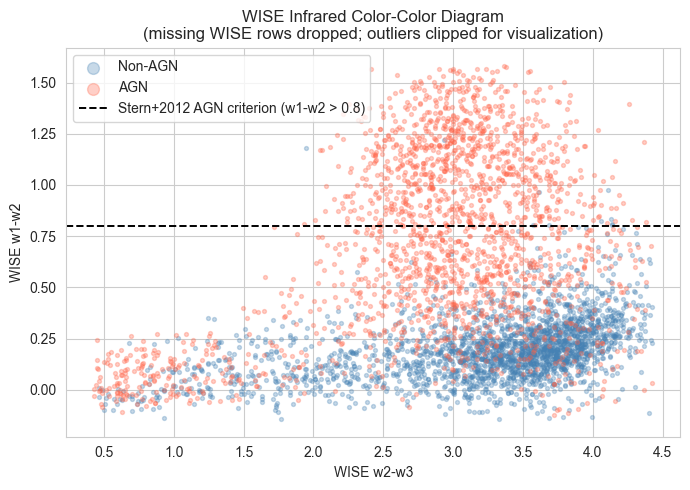

In [10]:
x_col, y_col = 'w2-w3', 'w1-w2'

# Only use rows where both WISE columns are present
df_wise_plot = df[[x_col, y_col, 'is_AGN']].dropna()

# Compute percentile clip bounds from complete rows only
x_lo, x_hi = df_wise_plot[x_col].quantile(0.01), df_wise_plot[x_col].quantile(0.99)
y_lo, y_hi = df_wise_plot[y_col].quantile(0.01), df_wise_plot[y_col].quantile(0.99)

# Apply mask — keep only rows within both bounds (visual outlier removal)
mask = (
    df_wise_plot[x_col].between(x_lo, x_hi) &
    df_wise_plot[y_col].between(y_lo, y_hi)
)
df_wise_viz = df_wise_plot[mask]
n_removed = len(df_wise_plot) - mask.sum()
print(f'Galaxies with WISE measurements: {len(df_wise_plot)} / {len(df)}')
print(f'Further outliers removed for plot (1st-99th pct clip): {n_removed} rows')

fig, ax = plt.subplots(figsize=(7, 5))
for label, color, name in [(0, 'steelblue', 'Non-AGN'), (1, 'tomato', 'AGN')]:
    subset = df_wise_viz[df_wise_viz['is_AGN'] == label]
    ax.scatter(subset[x_col], subset[y_col],
               alpha=0.3, s=8, c=color, label=name)
ax.axhline(y=0.8, color='black', linestyle='--', linewidth=1.4,
           label='Stern+2012 AGN criterion (w1-w2 > 0.8)')
ax.set_xlabel('WISE w2-w3')
ax.set_ylabel('WISE w1-w2')
ax.set_title('WISE Infrared Color-Color Diagram\n(missing WISE rows dropped; outliers clipped for visualization)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

---
## 3. Feature Groups & Column Definitions

We define four feature subsets that will each be used to train separate models. Running models on subsets is a better test of which *types* of measurements are most diagnostic — most models perform well given 20+ features, but performance on smaller subsets reveals which physical signals are actually useful.

| Subset | Columns | Physical meaning | Expected missingness |
|---|---|---|---|
| **All features** | All 20 below | Full combined feature set | Rows missing any feature dropped |
| **Emission line ratios** | `o3_hB`, `n2_hA`, `s2_hA`, `o1_hA`, `o3_o2`, `ne3_o2` | Log-ratio AGN diagnostics from optical spectroscopy (BPT, etc.) | ~50% of rows missing — only spectroscopic galaxies have these |
| **WISE infrared colors** | `w1-w2` through `w3-w4` (6 features) | Mid-IR color differences; AGN have warm dust signatures | ~10% missing |
| **SDSS optical colors** | `u-g` through `i-z` (10 features) | Optical broadband color differences | Nearly complete — photometric survey |

**Columns excluded from all models:**

| Column type | Examples | Why excluded |
|---|---|---|
| ID / catalog columns | `ext_ID`, `objID`, `specObjID`, `Unnamed: 0` | Reference numbers — using them causes data leakage (model memorizes IDs, not patterns) |
| Redshift | `z` | Biased in training set due to sample construction |
| Secondary target | `which_AGN` | Another form of the answer — using it as input is cheating |
| Raw flux columns | `h_alpha_flux`, etc. | Already encoded in the log-ratio features, which are more physically meaningful and scale-invariant |

In [11]:
# ── Column definitions ──────────────────────────────────────────────────────

TARGET = 'is_AGN'

# Columns to drop entirely from all models
ID_COLS       = ['ext_ID', 'objID', 'specObjID', 'Unnamed: 0']
REDSHIFT_COLS = ['z']          # biased in training set — excluded from all models
FLUX_COLS     = ['h_alpha_flux', 'h_beta_flux', 'oiii_5007_flux', 'nii_6584_flux',
                 'sii_6717_flux', 'sii_6731_flux', 'oi_6300_flux', 'oii_3726_flux',
                 'neiii_3869_flux', 'wise_cntr']
ALWAYS_DROP   = ID_COLS + REDSHIFT_COLS + ['which_AGN'] + FLUX_COLS + [TARGET]
ALWAYS_DROP   = [c for c in ALWAYS_DROP if c in df.columns]

# Feature subsets — each will be used to build a separate pair of models
EMISSION_COLS = ['o3_hB', 'n2_hA', 's2_hA', 'o1_hA', 'o3_o2', 'ne3_o2']
WISE_COLS     = ['w1-w2', 'w1-w3', 'w1-w4', 'w2-w3', 'w2-w4', 'w3-w4']
SDSS_COLS     = ['u-g', 'u-r', 'u-i', 'u-z', 'g-r', 'g-i', 'g-z', 'r-i', 'r-z', 'i-z']
ALL_FEATURE_COLS = EMISSION_COLS + WISE_COLS + SDSS_COLS

# Dictionary for easy iteration: subset_name → list of feature columns
FEATURE_SUBSETS = {
    'All features'            : ALL_FEATURE_COLS,
    'Emission line ratios'    : EMISSION_COLS,
    'WISE infrared colors'    : WISE_COLS,
    'SDSS optical colors'     : SDSS_COLS,
}

print('Feature subsets defined:')
for name, cols in FEATURE_SUBSETS.items():
    print(f'  {name}: {len(cols)} features → {cols}')

Feature subsets defined:
  All features: 22 features → ['o3_hB', 'n2_hA', 's2_hA', 'o1_hA', 'o3_o2', 'ne3_o2', 'w1-w2', 'w1-w3', 'w1-w4', 'w2-w3', 'w2-w4', 'w3-w4', 'u-g', 'u-r', 'u-i', 'u-z', 'g-r', 'g-i', 'g-z', 'r-i', 'r-z', 'i-z']
  Emission line ratios: 6 features → ['o3_hB', 'n2_hA', 's2_hA', 'o1_hA', 'o3_o2', 'ne3_o2']
  WISE infrared colors: 6 features → ['w1-w2', 'w1-w3', 'w1-w4', 'w2-w3', 'w2-w4', 'w3-w4']
  SDSS optical colors: 10 features → ['u-g', 'u-r', 'u-i', 'u-z', 'g-r', 'g-i', 'g-z', 'r-i', 'r-z', 'i-z']


---
## 4. Helper Function: Prepare a Feature Subset

For each subset, we need to:
1. Select only the relevant feature columns
2. **Drop rows that have any NaN in those columns** (rather than imputing)
3. Split into 80/20 train/test with stratification
4. Scale features to zero mean and unit variance

This function encapsulates all four steps for reuse across subsets.

**Why we drop instead of impute here:**  
When we select, say, only emission line ratio columns, any row missing those measurements is genuinely uninformative for this model — we have no spectroscopic data for it. Filling with a median would invent a measurement that was never made. By dropping, we ensure the model only trains and evaluates on galaxies that actually have the data it needs. For the SDSS color subset, almost no rows are dropped because SDSS photometry is nearly complete.

In [12]:
def prepare_subset(df_full, feature_cols, target_col='is_AGN',
                   test_size=0.20, random_state=42):
    """
    Prepare a feature subset for modeling.

    Steps:
      1. Select the target and the specified feature columns.
      2. Drop any row that has a NaN in ANY of the selected feature columns.
         We do NOT impute — a missing measurement means the observation is
         unsuitable for this model, not that we should guess a value.
      3. Stratified 80/20 train/test split (preserves AGN fraction in each set).
      4. StandardScaler fit on training set, applied to both sets.
         (Scaler is fit only on training data to prevent leakage.)

    Returns:
      X_train_sc, X_test_sc : scaled numpy arrays
      y_train, y_test       : target Series
      scaler                : fitted StandardScaler (for later inference)
      n_dropped             : number of rows removed for missing features
    """
    # Select relevant columns and drop rows with ANY missing value in features
    subset = df_full[feature_cols + [target_col]].copy()
    n_before = len(subset)
    subset = subset.dropna(subset=feature_cols)   # drop NaN rows for this subset's features
    n_dropped = n_before - len(subset)

    X = subset[feature_cols]
    y = subset[target_col].astype(int)

    # Stratified train/test split — preserves AGN ratio in both sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Scale features: fit on training data ONLY, then apply to test data
    # Fitting on test data would constitute data leakage and inflate scores
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # Sanity checks — no NaN or inf should remain after our cleaning steps
    assert not np.isnan(X_train_sc).any(), 'ERROR: NaN in scaled training data!'
    assert not np.isinf(X_train_sc).any(), 'ERROR: Inf in scaled training data!'
    assert not np.isnan(X_test_sc).any(),  'ERROR: NaN in scaled test data!'
    assert not np.isinf(X_test_sc).any(),  'ERROR: Inf in scaled test data!'

    return X_train_sc, X_test_sc, y_train, y_test, scaler, n_dropped


print('Helper function defined.')
print()

# Preview row counts for each subset so we know how much data each model will see
print('=== Row counts after dropping NaN rows per subset ===')
for name, cols in FEATURE_SUBSETS.items():
    subset = df[cols + [TARGET]].dropna(subset=cols)
    n_dropped = len(df) - len(subset)
    print(f'  {name:<30}  Rows: {len(subset):>4}  '
          f'(dropped {n_dropped}, {n_dropped/len(df):.1%} of total)')

Helper function defined.

=== Row counts after dropping NaN rows per subset ===
  All features                    Rows: 2077  (dropped 3061, 59.6% of total)
  Emission line ratios            Rows: 2139  (dropped 2999, 58.4% of total)
  WISE infrared colors            Rows: 4593  (dropped 545, 10.6% of total)
  SDSS optical colors             Rows: 5138  (dropped 0, 0.0% of total)


---
## 5. Helper Function: Train & Evaluate Models on a Subset

This function:
1. Takes pre-prepared scaled data for a subset
2. Trains both Logistic Regression and SVM
3. Runs 5-fold stratified cross-validation on the training data
4. Evaluates both models on the held-out test set
5. Returns all predictions and scores for later comparison

**Cross-validation:** Before looking at the test set, we run **5-fold stratified CV** on the training data — split into 5 chunks, train on 4, evaluate on the 5th, rotate, average. This is more reliable than a single evaluation and helps detect overfitting.

**ROC-AUC** is used as our primary metric — it measures how well the model ranks AGN above non-AGN across all probability thresholds, regardless of where the cut is set. AUC = 1.0 is perfect; AUC = 0.5 is random chance.

In [13]:
def train_and_evaluate(X_train_sc, X_test_sc, y_train, y_test, subset_name):
    """
    Train Logistic Regression and SVM on a pre-scaled subset,
    run 5-fold CV, and evaluate on the test set.

    Returns a dict with all predictions, probabilities, CV scores,
    and fitted model objects.
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = {}

    # ── Logistic Regression ─────────────────────────────────────────────────
    # C=1.0: moderate regularization; L2: ridge penalty shrinks all coefficients
    # max_iter=1000: enough iterations to guarantee convergence
    lr = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs',
                            max_iter=1000, random_state=42)
    lr.fit(X_train_sc, y_train)

    lr_cv = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='roc_auc')
    lr_pred  = lr.predict(X_test_sc)
    lr_proba = lr.predict_proba(X_test_sc)[:, 1]

    results['lr'] = {
        'model'    : lr,
        'cv_scores': lr_cv,
        'y_pred'   : lr_pred,
        'y_proba'  : lr_proba,
    }

    # ── SVM with RBF kernel ──────────────────────────────────────────────────
    # RBF kernel: allows curved, non-linear decision boundaries
    # gamma='scale': 1 / (n_features × feature_variance) — auto-tuned
    # probability=True: enables predict_proba() for ROC-AUC (adds minor overhead)
    svm = SVC(C=1.0, kernel='rbf', gamma='scale',
              probability=True, random_state=42)
    svm.fit(X_train_sc, y_train)

    svm_cv = cross_val_score(svm, X_train_sc, y_train, cv=cv, scoring='roc_auc')
    svm_pred  = svm.predict(X_test_sc)
    svm_proba = svm.predict_proba(X_test_sc)[:, 1]

    results['svm'] = {
        'model'    : svm,
        'cv_scores': svm_cv,
        'y_pred'   : svm_pred,
        'y_proba'  : svm_proba,
    }

    # ── Print summary ────────────────────────────────────────────────────────
    print(f'\n{'='*60}')
    print(f'  Subset: {subset_name}')
    print(f'  Train: {len(y_train)} rows  |  Test: {len(y_test)} rows')
    print(f'{'='*60}')

    for model_name, key in [('Logistic Regression', 'lr'), ('SVM (RBF)', 'svm')]:
        r = results[key]
        print(f'\n  {model_name}:')
        print(f'    CV ROC-AUC:  {r["cv_scores"].mean():.4f} ± {r["cv_scores"].std():.4f}')
        print(f'    Test AUC:    {roc_auc_score(y_test, r["y_proba"]):.4f}')
        print(f'    Test Acc:    {accuracy_score(y_test, r["y_pred"]):.4f}')

    return results


print('Training/evaluation helper function defined.')

Training/evaluation helper function defined.


---
## 6. Run Models on All Four Feature Subsets

We now loop over all four feature subsets and run both models on each. Key points:

- **Each subset uses only its own rows** — galaxies missing that subset's features are dropped, not filled in.
- The emission line subset will use roughly **half as many rows** as the photometric subsets because many galaxies lack spectroscopy.
- SDSS optical colors will use the **full dataset** — photometric coverage is essentially complete.
- This tests whether simpler, single-type feature sets can still classify AGN well.

In [14]:
# Store all results for comparison in Section 7
all_results = {}     # all_results[subset_name] = {'lr': {...}, 'svm': {...}}
all_data    = {}     # all_data[subset_name]    = (X_train_sc, X_test_sc, y_train, y_test, scaler)

for subset_name, feature_cols in FEATURE_SUBSETS.items():
    # Step 1: Drop rows with NaN in this subset's columns, then split and scale
    X_tr, X_te, y_tr, y_te, scaler, n_dropped = prepare_subset(
        df, feature_cols, target_col=TARGET
    )

    # Step 2: Train LR + SVM, run 5-fold CV, evaluate on test set
    results = train_and_evaluate(X_tr, X_te, y_tr, y_te, subset_name)

    # Store for later
    all_results[subset_name] = results
    all_data[subset_name]    = (X_tr, X_te, y_tr, y_te, scaler, feature_cols)

print('\n\nAll subsets trained and evaluated.')


  Subset: All features
  Train: 1661 rows  |  Test: 416 rows

  Logistic Regression:
    CV ROC-AUC:  0.9820 ± 0.0165
    Test AUC:    0.9500
    Test Acc:    0.9688

  SVM (RBF):
    CV ROC-AUC:  0.9947 ± 0.0038
    Test AUC:    0.9867
    Test Acc:    0.9688

  Subset: Emission line ratios
  Train: 1711 rows  |  Test: 428 rows

  Logistic Regression:
    CV ROC-AUC:  0.9544 ± 0.0161
    Test AUC:    0.9688
    Test Acc:    0.9813

  SVM (RBF):
    CV ROC-AUC:  0.9828 ± 0.0082
    Test AUC:    0.9724
    Test Acc:    0.9766

  Subset: WISE infrared colors
  Train: 3674 rows  |  Test: 919 rows

  Logistic Regression:
    CV ROC-AUC:  0.8641 ± 0.0209
    Test AUC:    0.8724
    Test Acc:    0.8150

  SVM (RBF):
    CV ROC-AUC:  0.9388 ± 0.0084
    Test AUC:    0.9273
    Test Acc:    0.8651

  Subset: SDSS optical colors
  Train: 4110 rows  |  Test: 1028 rows

  Logistic Regression:
    CV ROC-AUC:  0.7536 ± 0.0128
    Test AUC:    0.7553
    Test Acc:    0.7743

  SVM (RBF):
    CV RO

---
## 7. Model Comparison & Evaluation

### 7a. Summary Table

We collect all metrics into a single table for easy comparison across subsets and models.

| Metric | Definition | Notes |
|---|---|---|
| **Accuracy** | % of all galaxies correctly labeled | Not our primary metric — can be misleading even with balanced classes. |
| **ROC-AUC** | Area under the ROC curve — how well the model ranks AGN above non-AGN | **Primary metric.** 1.0 = perfect, 0.5 = random. |
| **Precision** | Of galaxies predicted as AGN, what fraction actually are? | Measures false alarm rate. |
| **Recall** | Of all true AGN, what fraction did we catch? | Measures missed AGN — critical for discovery science. |
| **F1** | Harmonic mean of precision and recall | Balances both concerns. |

In [15]:
# Build a tidy summary table across all subsets and both models
rows = []
for subset_name, results in all_results.items():
    _, X_te, _, y_te, _, _ = all_data[subset_name]
    for model_key, model_label in [('lr', 'Logistic Regression'), ('svm', 'SVM (RBF)')]:
        r = results[model_key]
        rows.append({
            'Subset'         : subset_name,
            'Model'          : model_label,
            'N (test rows)'  : len(y_te),
            'CV AUC (mean)'  : r['cv_scores'].mean(),
            'CV AUC (std)'   : r['cv_scores'].std(),
            'Test AUC'       : roc_auc_score(y_te, r['y_proba']),
            'Test Accuracy'  : accuracy_score(y_te, r['y_pred']),
            'Test Precision' : precision_score(y_te, r['y_pred']),
            'Test Recall'    : recall_score(y_te, r['y_pred']),
            'Test F1'        : f1_score(y_te, r['y_pred']),
        })

summary_df = pd.DataFrame(rows).set_index(['Subset', 'Model']).round(4)
print('=== Full Model Comparison (all subsets, both models) ===')
summary_df

=== Full Model Comparison (all subsets, both models) ===


N (test rows)  CV AUC (mean)  \
Subset               Model                                               
All features         Logistic Regression            416         0.9820   
                     SVM (RBF)                      416         0.9947   
Emission line ratios Logistic Regression            428         0.9544   
                     SVM (RBF)                      428         0.9828   
WISE infrared colors Logistic Regression            919         0.8641   
                     SVM (RBF)                      919         0.9388   
SDSS optical colors  Logistic Regression           1028         0.7536   
                     SVM (RBF)                     1028         0.9387   

                                          CV AUC (std)  Test AUC  \
Subset               Model                                         
All features         Logistic Regression        0.0165    0.9500   
                     SVM (RBF)                  0.0038    0.9867   
Emission line ratios Logistic Regression        0.0161    0.9688   
                     SVM (RBF)                  0.0082    0.9724   
WISE infrared colors Logistic Regression        0.0209    0.8724   
                     SVM (RBF)                  0.0084    0.9273   
SDSS optical colors  Logistic Regression        0.0128    0.7553   
                     SVM (RBF)                  0.0098    0.9367   

                                          Test Accuracy  Test Precision  \
Subset               Model                                                
All features         Logistic Regression         0.9688          0.9649   
                     SVM (RBF)                   0.9688          1.0000   
Emission line ratios Logistic Regression         0.9813          1.0000   
                     SVM (RBF)                   0.9766          0.9531   
WISE infrared colors Logistic Regression         0.8150          0.8997   
                     SVM (RBF)                   0.8651          0.8716   
SDSS optical colors  Logistic Regression         0.7743          0.8294   
                     SVM (RBF)                   0.8706          0.9150   

                                          Test Recall  Test F1  
Subset               Model                                      
All features         Logistic Regression       0.8333   0.8943  
                     SVM (RBF)                 0.8030   0.8908  
Emission line ratios Logistic Regression       0.8824   0.9375  
                     SVM (RBF)                 0.8971   0.9242  
WISE infrared colors Logistic Regression       0.6753   0.7715  
                     SVM (RBF)                 0.8306   0.8506  
SDSS optical colors  Logistic Regression       0.6907   0.7537  
                     SVM (RBF)                 0.8171   0.8633

### 7b. ROC Curves — All Subsets

ROC curves show True Positive Rate (recall) vs. False Positive Rate across all probability thresholds. A curve hugging the top-left corner is better. The dashed diagonal represents random guessing (AUC = 0.5).

Plotting all four subsets together allows direct visual comparison of which feature type provides the most discriminating signal.

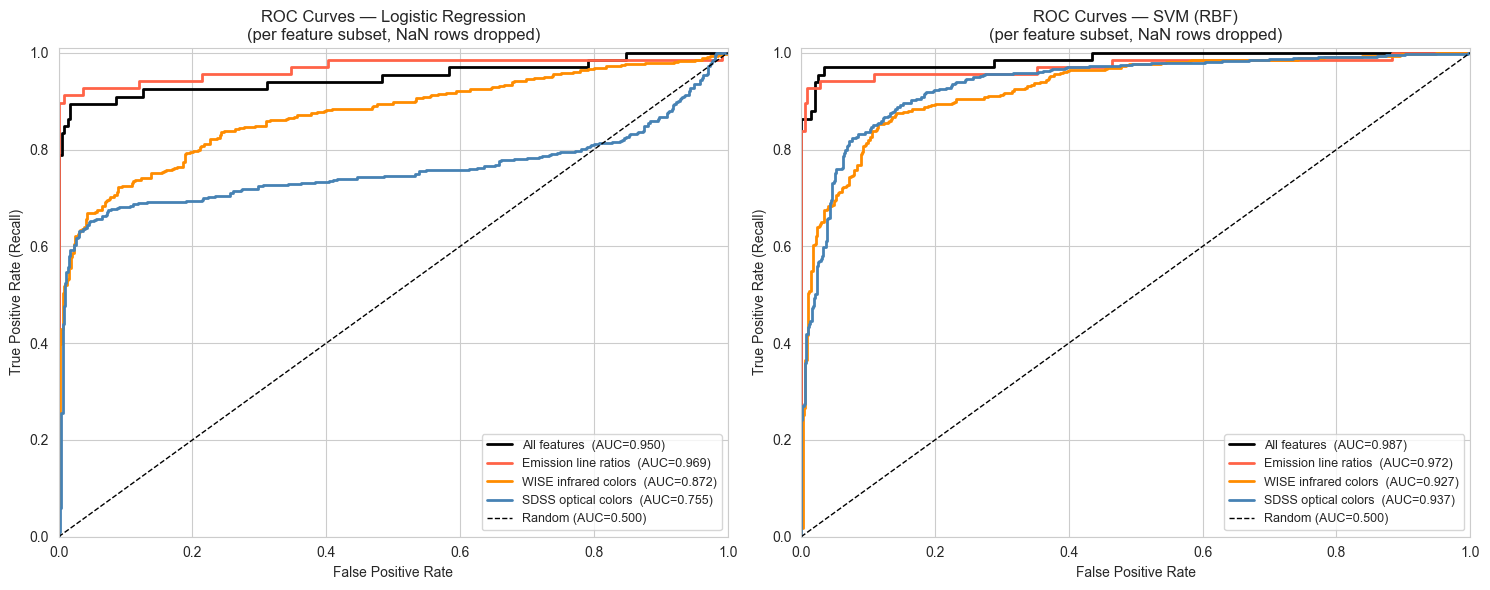

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Color map — one color per subset
colors = {'All features': 'black', 'Emission line ratios': 'tomato',
          'WISE infrared colors': 'darkorange', 'SDSS optical colors': 'steelblue'}

for ax, (model_key, model_label) in zip(axes, [('lr', 'Logistic Regression'), ('svm', 'SVM (RBF)')]):
    for subset_name, results in all_results.items():
        _, _, _, y_te, _, _ = all_data[subset_name]
        y_proba = results[model_key]['y_proba']
        auc_val = roc_auc_score(y_te, y_proba)
        fpr, tpr, _ = roc_curve(y_te, y_proba)
        ax.plot(fpr, tpr, label=f'{subset_name}  (AUC={auc_val:.3f})',
                color=colors[subset_name], linewidth=2)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title(f'ROC Curves — {model_label}\n(per feature subset, NaN rows dropped)')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.01])

plt.tight_layout()
plt.show()

### 7c. Confusion Matrices — All Subsets

Confusion matrices show the exact counts of correct and incorrect predictions for each class.

**Cells:**
- TN (top-left): non-AGN correctly identified
- FP (top-right): non-AGN wrongly flagged as AGN
- **FN (bottom-left): real AGN we missed ← highest cost for discovery science**
- TP (bottom-right): AGN correctly identified

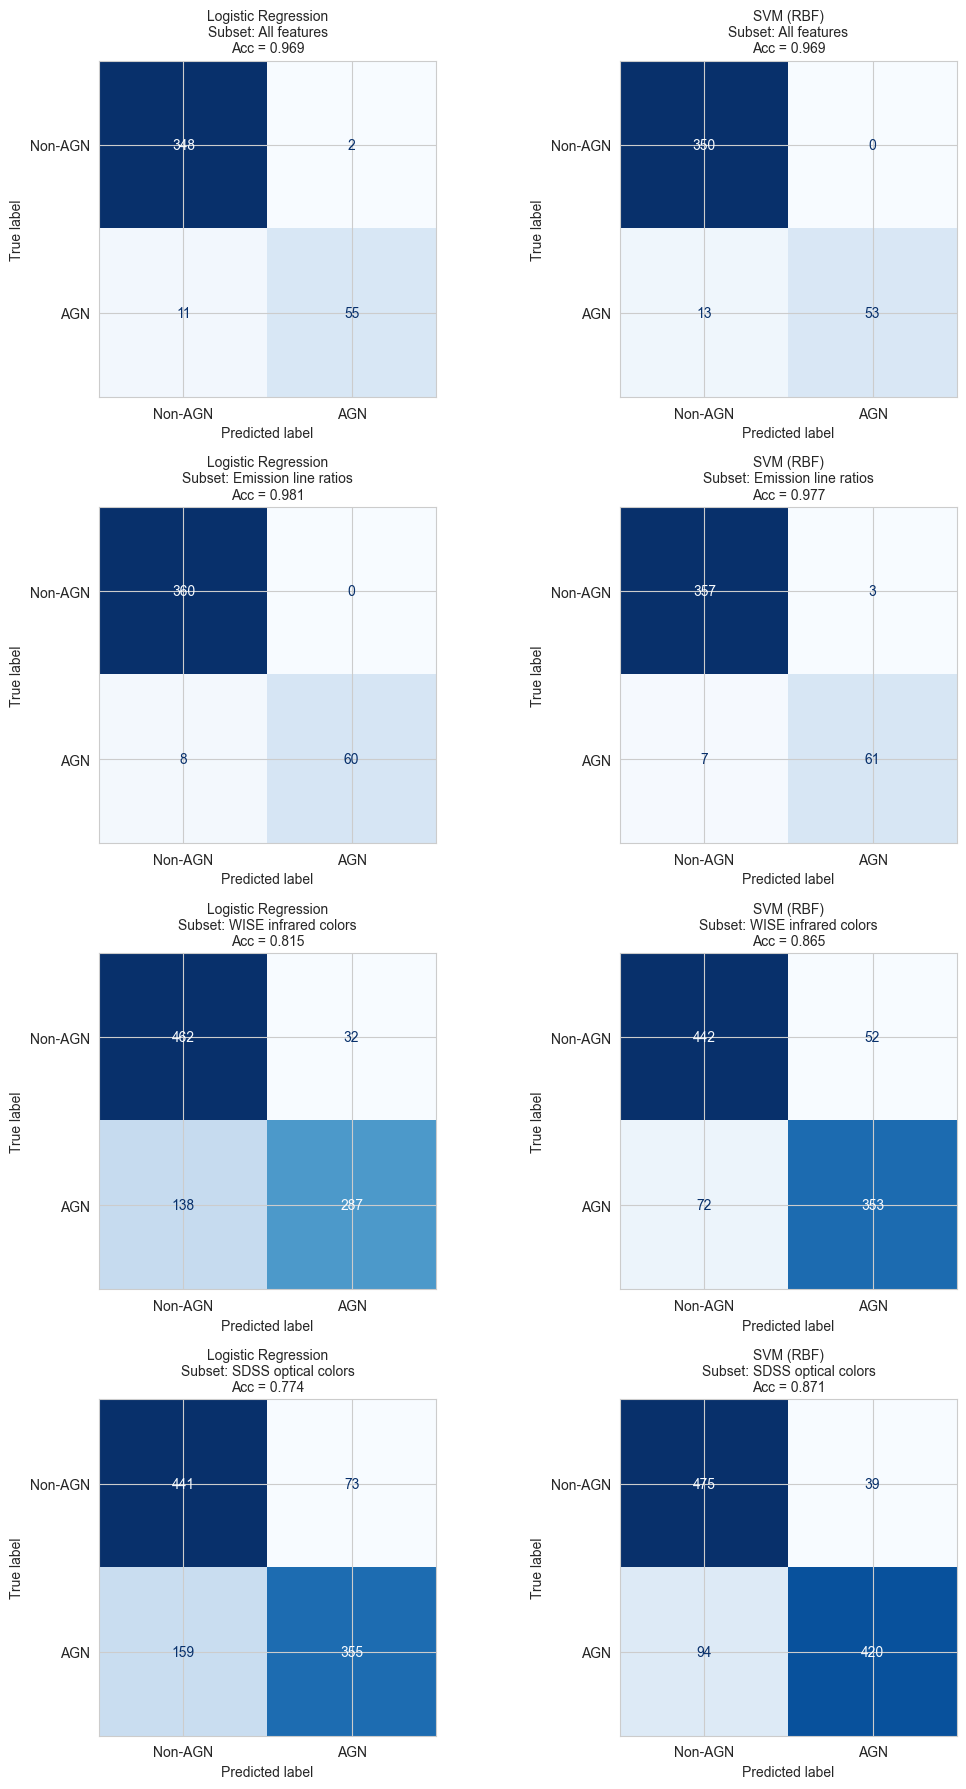

In [17]:
n_subsets = len(FEATURE_SUBSETS)
fig, axes = plt.subplots(n_subsets, 2, figsize=(11, 4.5 * n_subsets))

for row_idx, (subset_name, results) in enumerate(all_results.items()):
    _, _, _, y_te, _, _ = all_data[subset_name]

    for col_idx, (model_key, model_label) in enumerate(
        [('lr', 'Logistic Regression'), ('svm', 'SVM (RBF)')]  
    ):
        ax = axes[row_idx, col_idx]
        y_pred = results[model_key]['y_pred']
        cm = confusion_matrix(y_te, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=['Non-AGN', 'AGN']).plot(
            ax=ax, colorbar=False, cmap='Blues'
        )
        acc = accuracy_score(y_te, y_pred)
        ax.set_title(f'{model_label}\nSubset: {subset_name}\nAcc = {acc:.3f}',
                     fontsize=10)

plt.tight_layout()
plt.show()

### 7d. Cross-Validation AUC Comparison — All Subsets

Boxplots of 5-fold CV AUC for every subset × model combination. A tight box with a high median = consistently reliable. A wide box = variable performance across folds, possibly due to smaller sample sizes (e.g., the emission line subset has fewer rows).

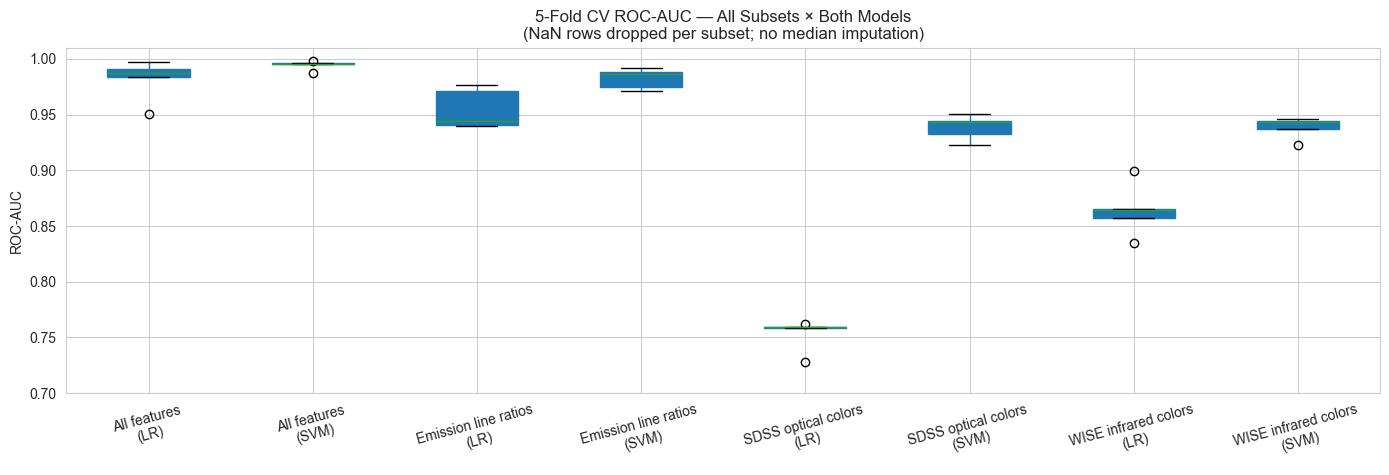

In [18]:
# Build a long-form DataFrame for boxplotting
cv_rows = []
for subset_name, results in all_results.items():
    for model_key, model_label in [('lr', 'LR'), ('svm', 'SVM')]:
        for fold_auc in results[model_key]['cv_scores']:
            cv_rows.append({
                'Label'  : f'{subset_name}\n({model_label})',
                'ROC-AUC': fold_auc
            })
cv_df = pd.DataFrame(cv_rows)

fig, ax = plt.subplots(figsize=(14, 5))
cv_df.boxplot(column='ROC-AUC', by='Label', ax=ax, rot=15,
              patch_artist=True, grid=True)
ax.set_title('5-Fold CV ROC-AUC — All Subsets × Both Models\n'
             '(NaN rows dropped per subset; no median imputation)')
ax.set_xlabel('')
ax.set_ylabel('ROC-AUC')
ax.set_ylim([0.70, 1.01])
plt.suptitle('')   # suppress default "Boxplot grouped by" title
plt.tight_layout()
plt.show()

### 7e. Feature Importance — Logistic Regression Coefficients

Because all features were standardized to the same scale, the **magnitude of each LR coefficient** directly reflects that feature's influence on the prediction — values are comparable across all features.

- **Red (positive coefficient):** Feature pushes prediction toward AGN
- **Blue (negative coefficient):** Feature pushes prediction toward non-AGN

This is shown only for the **All features** model (the most interpretable version using the full feature set) and separately for each subset model, so we can compare which features matter most in isolation vs. combined.

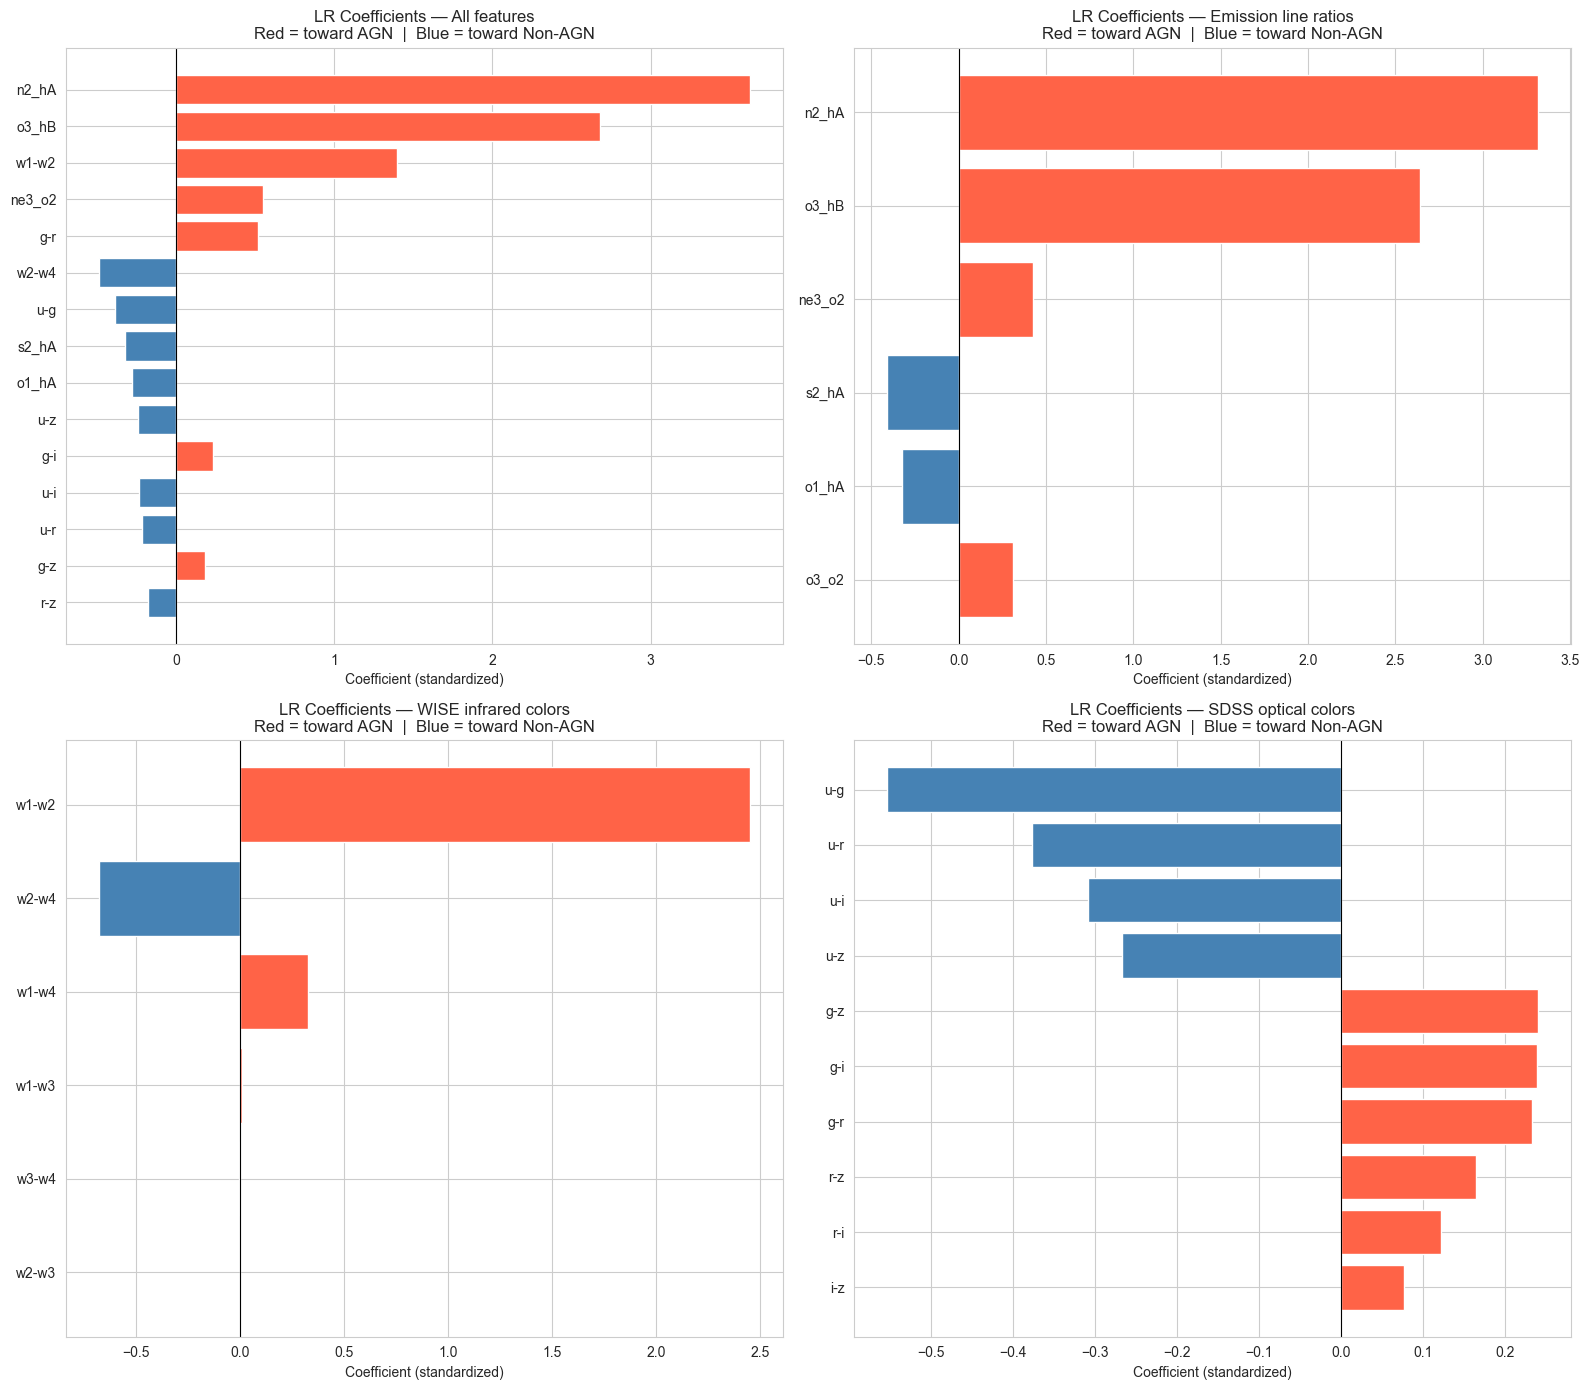

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, (subset_name, results) in zip(axes, all_results.items()):
    lr_model = results['lr']['model']
    _, _, _, _, _, feature_cols = all_data[subset_name]

    coef_df = pd.DataFrame({'feature': feature_cols,
                            'coefficient': lr_model.coef_[0]})
    coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)

    # Show up to 15 features per panel
    top = coef_df.head(min(15, len(coef_df)))
    colors = ['tomato' if c > 0 else 'steelblue' for c in top['coefficient']]

    ax.barh(top['feature'], top['coefficient'], color=colors)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('Coefficient (standardized)')
    ax.set_title(f'LR Coefficients — {subset_name}\n'
                 'Red = toward AGN  |  Blue = toward Non-AGN')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

---
## 8. Detailed Classification Reports (per subset)

Full per-class precision, recall, and F1 for every subset × model combination, printed together for review.

In [22]:
for subset_name, results in all_results.items():
    _, _, _, y_te, _, _ = all_data[subset_name]
    print(f'\n{"="*60}')
    print(f'  Subset: {subset_name}  |  Test rows: {len(y_te)}')
    print(f'{"="*60}')
    for model_key, model_label in [('lr', 'Logistic Regression'), ('svm', 'SVM (RBF)')]:
        r = results[model_key]
        print(f'\n  --- {model_label} ---')
        print(f'  CV AUC: {r["cv_scores"].mean():.4f} ± {r["cv_scores"].std():.4f}')
        print(classification_report(y_te, r['y_pred'], target_names=['Non-AGN', 'AGN']
        ))


  Subset: All features  |  Test rows: 416

  --- Logistic Regression ---
  CV AUC: 0.9820 ± 0.0165
              precision    recall  f1-score   support

     Non-AGN       0.97      0.99      0.98       350
         AGN       0.96      0.83      0.89        66

    accuracy                           0.97       416
   macro avg       0.97      0.91      0.94       416
weighted avg       0.97      0.97      0.97       416


  --- SVM (RBF) ---
  CV AUC: 0.9947 ± 0.0038
              precision    recall  f1-score   support

     Non-AGN       0.96      1.00      0.98       350
         AGN       1.00      0.80      0.89        66

    accuracy                           0.97       416
   macro avg       0.98      0.90      0.94       416
weighted avg       0.97      0.97      0.97       416


  Subset: Emission line ratios  |  Test rows: 428

  --- Logistic Regression ---
  CV AUC: 0.9544 ± 0.0161
              precision    recall  f1-score   support

     Non-AGN       0.98      1.00   

---
## 9. Apply Best Model to `test_dataset.csv` (Unlabeled Inference)

With models evaluated, we select the best-performing subset × model combination from Section 7 and apply it to all **42,814 unlabeled SDSS galaxies** in `test_dataset.csv`.

For inference, we apply the **same cleaning and scaling** that was used during training:
1. Convert `±inf` → `NaN` (same as training)
2. Keep only rows that have all required feature columns present — no imputation
3. Apply the **same fitted scaler** from training — never refit on inference data

Galaxies missing the required features are set aside and not classified by this subset's model. If full population coverage is needed, the SDSS color subset (which has near-complete coverage) may be preferred.

**Edit the two variables below** to choose your best model:

In [27]:
# ── Configuration: choose the best subset and model from Section 7 ──────────
# Change these based on the summary table above.
# subset must be one of the keys in FEATURE_SUBSETS.
# model_key is 'lr' (Logistic Regression) or 'svm' (SVM with RBF kernel).

BEST_SUBSET    = 'All features'   # change if a different subset performed best
BEST_MODEL_KEY = 'svm'            # 'lr' or 'svm'

# ── Load inference data ──────────────────────────────────────────────────────
df_infer = pd.read_csv('test_dataset.csv')
print(f'Inference dataset shape: {df_infer.shape}')

# Step 1: Convert ±inf to NaN (same transformation as applied to training data)
df_infer = df_infer.replace([np.inf, -np.inf], np.nan)

# Step 2: Retrieve the feature list and fitted scaler for the chosen subset
_, _, _, _, best_scaler, best_feature_cols = all_data[BEST_SUBSET]
best_model = all_results[BEST_SUBSET][BEST_MODEL_KEY]['model']

print(f'\nBest subset:    {BEST_SUBSET}  ({len(best_feature_cols)} features)')
print(f'Best model:     {"Logistic Regression" if BEST_MODEL_KEY == "lr" else "SVM (RBF)"}')
print(f'Features used:  {best_feature_cols}')

Inference dataset shape: (42814, 45)

Best subset:    All features  (22 features)
Best model:     SVM (RBF)
Features used:  ['o3_hB', 'n2_hA', 's2_hA', 'o1_hA', 'o3_o2', 'ne3_o2', 'w1-w2', 'w1-w3', 'w1-w4', 'w2-w3', 'w2-w4', 'w3-w4', 'u-g', 'u-r', 'u-i', 'u-z', 'g-r', 'g-i', 'g-z', 'r-i', 'r-z', 'i-z']


In [29]:
# Step 3: Select the required feature columns from the inference dataset
X_infer_raw = df_infer[best_feature_cols].copy()

# Step 4: Identify rows that are complete (no NaN in any required feature)
# We cannot classify galaxies that are missing the features this model was trained on.
# Rather than guessing (imputing), we separate them out.
complete_mask = X_infer_raw.notna().all(axis=1)
n_complete  = complete_mask.sum()
n_missing   = (~complete_mask).sum()

print(f'Inference rows with complete features ({BEST_SUBSET}): '
      f'{n_complete} / {len(df_infer)} ({n_complete/len(df_infer):.1%})')
print(f'Rows lacking ≥1 required feature (not classified): '
      f'{n_missing} ({n_missing/len(df_infer):.1%})')

X_infer_complete = X_infer_raw[complete_mask]

# Step 5: Apply the SAME scaler fitted on training data — never refit on inference
X_infer_scaled = best_scaler.transform(X_infer_complete)

print(f'\nInference feature matrix shape (complete rows only): {X_infer_scaled.shape}')

Inference rows with complete features (All features): 13709 / 42814 (32.0%)
Rows lacking ≥1 required feature (not classified): 29105 (68.0%)

Inference feature matrix shape (complete rows only): (13709, 22)


In [30]:
# Step 6: Generate predictions for complete rows
infer_preds  = best_model.predict(X_infer_scaled)
infer_probas = best_model.predict_proba(X_infer_scaled)[:, 1]

# Step 7: Write predictions back to the inference DataFrame (complete rows only)
# Rows that were missing features get NaN for both prediction columns.
df_infer['pred_is_AGN']    = np.nan
df_infer['pred_AGN_proba'] = np.nan
df_infer.loc[complete_mask, 'pred_is_AGN']    = infer_preds
df_infer.loc[complete_mask, 'pred_AGN_proba'] = infer_probas.round(4)

n_agn = int(infer_preds.sum())
print(f'Classified galaxies:   {n_complete}')
print(f'Predicted AGN:         {n_agn} / {n_complete} ({n_agn/n_complete:.1%})')

# High-confidence AGN candidates (probability > 0.80)
high_conf = df_infer[df_infer['pred_AGN_proba'] > 0.80]
print(f'High-confidence AGN (prob > 0.80): {len(high_conf)}')

df_infer[['objID', 'pred_is_AGN', 'pred_AGN_proba']].head(10)

Classified galaxies:   13709
Predicted AGN:         9586 / 13709 (69.9%)
High-confidence AGN (prob > 0.80): 9302


,objID,pred_is_AGN,pred_AGN_proba
0,1237651250947293276,0.0,0.0569
1,1237651272961622132,NaN,NaN
2,1237651272425275578,1.0,1.0000
3,1237651192433344532,NaN,NaN
4,1237651533873873037,1.0,0.9949
5,1237654605866074191,1.0,0.9899
6,1237661063871594762,1.0,1.0000
7,1237662619189903666,1.0,1.0000
8,1237662619724873992,0.0,0.0589
9,1237671938743011428,NaN,NaN


Saved predictions to test_predictions.csv
(29105 rows have NaN predictions — missing features for All features subset)


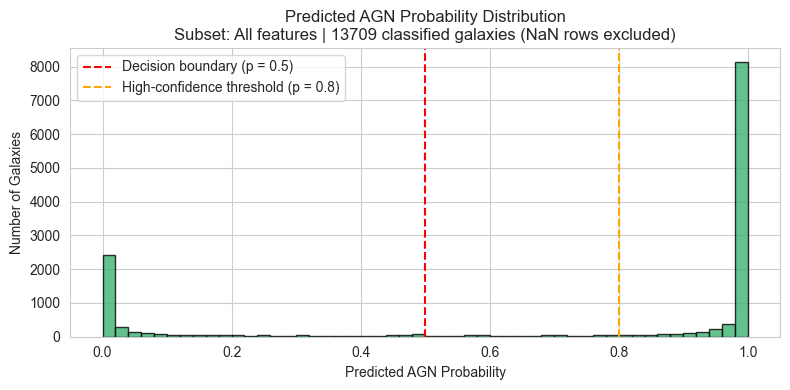

In [31]:
# Save predictions
df_infer[['objID', 'pred_is_AGN', 'pred_AGN_proba']].to_csv('test_predictions.csv', index=False)
print('Saved predictions to test_predictions.csv')
print(f'({n_missing} rows have NaN predictions — missing features for {BEST_SUBSET} subset)')

# Plot the predicted probability distribution for classified galaxies
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(infer_probas, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.8)
ax.axvline(x=0.5, color='red',    linestyle='--', label='Decision boundary (p = 0.5)')
ax.axvline(x=0.8, color='orange', linestyle='--', label='High-confidence threshold (p = 0.8)')
ax.set_xlabel('Predicted AGN Probability')
ax.set_ylabel('Number of Galaxies')
ax.set_title(f'Predicted AGN Probability Distribution\nSubset: {BEST_SUBSET} '
             f'| {n_complete} classified galaxies (NaN rows excluded)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Summary

| Step | What we did |
|---|---|
| **Data** | Loaded `train_dataset.csv` (5,138 labeled galaxies, ~50/50 AGN) |
| **Redshift excluded** | `z` dropped — biased in training set due to sample construction |
| **inf → NaN** | `±inf` from log-ratio features (zero-flux denominators) converted to `NaN` |
| **No imputation** | Rows missing features in a given subset are **dropped**, not filled with median values, to avoid fabricating measurements |
| **Feature subsets** | Models run on 4 subsets: All features, Emission line ratios, WISE infrared colors, SDSS optical colors |
| **Emission lines** | ~50% of rows dropped (galaxies without spectroscopy have no emission line data) |
| **WISE / SDSS** | ~10% / 0% of rows dropped (photometric surveys are more complete) |
| **Models** | Logistic Regression (L2, C=1.0) + SVM (RBF kernel, C=1.0, gamma='scale') |
| **Evaluation** | 5-fold CV ROC-AUC · accuracy · precision · recall · F1 · confusion matrices · ROC curves |
| **Inference** | Applied best model to 42,814 unlabeled SDSS galaxies · rows missing required features left unclassified · saved to `test_predictions.csv` |